# 04 — Modeling

**Milestone 3, Phase C onward.** Today: `HC-M3-09` (preprocessing pipeline), `HC-M3-10` (pipeline tests). Continues from `03_feature_engineering.ipynb` (Phases A + B) — that notebook's `docs/feature_engineering_strategy.md` and `docs/feature_leakage_audit.md` are the reference for everything built on here.

Loads the same development/holdout split (`data/interim/train_valid_split.csv`, `HC-M3-02`) via `config` (`HC-M3-03`). The holdout is not touched in this notebook until `HC-M3-21`.

In [1]:
import duckdb
import pandas as pd

from home_credit_default_risk import config

con = duckdb.connect(str(config.CACHE_DB), read_only=True)
application_train = con.sql("SELECT * FROM application_train").df()
con.close()

split = pd.read_csv(config.SPLIT_PATH)
dev_ids = split.loc[split["split"] == "train", "SK_ID_CURR"]
holdout_ids = split.loc[split["split"] == "valid", "SK_ID_CURR"]

development = application_train[
    application_train["SK_ID_CURR"].isin(dev_ids)
].reset_index(drop=True)

print(f"Development: {development.shape}")
print(f"Holdout ids reserved (not loaded as features here): {len(holdout_ids):,}")

Development: (246008, 122)
Holdout ids reserved (not loaded as features here): 61,503


## `HC-M3-09` — Leakage-safe preprocessing pipeline

Implemented in [`src/home_credit_default_risk/pipeline.py`](../src/home_credit_default_risk/pipeline.py), two deliberately separate functions:

- **`build_feature_matrix()`** — applies `HC-M3-05` + `HC-M3-06` feature engineering. Safe to apply once to the whole development pool rather than per CV fold, because (per `docs/feature_leakage_audit.md`) none of it fits a cross-row statistic — it's pure per-row/per-key computation, so the result is identical whether it's computed once or inside every fold.
- **`build_preprocessor()`** — an **unfitted** `ColumnTransformer` (median-impute + `RobustScaler` for numeric, most-frequent-impute + one-hot for categorical). This one *does* fit statistics from data, so it must only ever be fit inside a `Pipeline` on a training fold — `HC-M3-11`'s cross-validation is what actually exercises that discipline; this section only proves the pipeline mechanically works.

`TARGET` and `SK_ID_CURR` are dropped before `build_preprocessor()` ever sees the data — enforced by `tests/test_pipeline.py::test_preprocessor_column_lists_exclude_id_and_target`, not just by convention.

In [2]:
from home_credit_default_risk.pipeline import build_feature_matrix, build_preprocessor

con = duckdb.connect(str(config.CACHE_DB), read_only=True)
feature_matrix = build_feature_matrix(con, development.drop(columns=["TARGET"]))
con.close()

y = development["TARGET"]
X = feature_matrix.drop(columns=["SK_ID_CURR"])

assert len(X) == len(development), "Row count changed during feature engineering"

print(f"X: {X.shape}, y: {y.shape}")
print(f"Numeric columns: {X.select_dtypes(include='number').shape[1]}")
print(f"Categorical columns: {X.select_dtypes(exclude='number').shape[1]}")

X: (246008, 149), y: (246008,)
Numeric columns: 133
Categorical columns: 16


**Smoke test, not model selection** — proves the full `Pipeline` (preprocessing + an estimator) fits and predicts end-to-end on the real feature matrix. A single 80/20 split is fine for this; it is *not* how candidate models get compared (that's `HC-M3-11`'s cross-validation, next).

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

X_smoke_train, X_smoke_valid, y_smoke_train, y_smoke_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=config.RANDOM_STATE
)

smoke_pipeline = Pipeline(
    steps=[
        ("preprocess", build_preprocessor(X_smoke_train)),
        (
            "classify",
            LogisticRegression(
                class_weight="balanced", max_iter=1000, random_state=config.RANDOM_STATE
            ),
        ),
    ]
)
smoke_pipeline.fit(X_smoke_train, y_smoke_train)
smoke_proba = smoke_pipeline.predict_proba(X_smoke_valid)[:, 1]
smoke_auc = roc_auc_score(y_smoke_valid, smoke_proba)

print(f"Pipeline fit/predict smoke test ROC-AUC: {smoke_auc:.4f}")

/Users/shadman.arko/Documents/Work_DoNotTouch/Spiced/Projects/home-credit-default-risk/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline fit/predict smoke test ROC-AUC: 0.7521


### Summary — HC-M3-09 acceptance criteria

- [x] Numerical preprocessing defined (median impute + `RobustScaler`)
- [x] Categorical preprocessing defined (most-frequent impute + one-hot, `handle_unknown="ignore"`)
- [x] Missing-value strategy defined (same as above; feature-engineering-introduced `NaN`s — e.g. no bureau history — flow into this same imputer, no separate handling needed)
- [x] Transformations occur inside pipeline where appropriate (`build_preprocessor()` returns an unfitted `ColumnTransformer`; fit only happens inside a `Pipeline.fit()` call, demonstrated above)
- [x] Pipeline can fit/predict (smoke-tested above on the real feature matrix, ROC-AUC computed successfully)
- [x] No preprocessing leakage (nothing fit outside a `Pipeline`; feature engineering itself has no fittable state per `HC-M3-07`'s audit)

### Summary — HC-M3-10 acceptance criteria (`tests/test_pipeline.py`, 8 tests)

- [x] `fit()` (`test_preprocessor_fits_and_transforms`, `test_full_pipeline_fits_and_predicts`)
- [x] `predict()` (`test_full_pipeline_fits_and_predicts`, `test_pipeline_handles_unseen_category_at_predict_time`)
- [x] Expected columns (`test_build_feature_matrix_includes_engineered_and_raw_columns`)
- [x] Missing values (`test_preprocessor_output_has_no_missing_values`)
- [x] Output shape (`test_preprocessor_fits_and_transforms`, `test_build_feature_matrix_preserves_row_count`)
- [x] No target column in X (`test_preprocessor_column_lists_exclude_id_and_target`, `test_build_feature_matrix_does_not_require_target`)

This closes Milestone 3 Phase C. `HC-M3-11` (Stratified 5-fold CV) is next.

## `HC-M3-11` — Stratified K-Fold cross-validation

The `HC-M3-09` smoke test above used one 80/20 split — fine for proving the pipeline mechanically works, not sound for comparing candidates. One split gives one noisy number; a 0.003 difference between two models could just be which rows happened to land in that split's validation fold. `StratifiedKFold(n_splits=5, shuffle=True, random_state=config.RANDOM_STATE)`, implemented in [`src/home_credit_default_risk/cv.py`](../src/home_credit_default_risk/cv.py), reports **mean ± std across 5 folds** instead — every comparison from here on (`HC-M3-08`, `HC-M3-12`–`15`) uses this, never a single split.

Unit-tested (`tests/test_cv.py`, 6 tests) on synthetic data before touching real data: exactly `n_splits` fold scores, mean/std computed correctly, stratification keeps each fold's class balance within 5% of the overall rate, the same `random_state` reproduces identical results, and — the subtle one — a fresh, unfitted pipeline instance is used for every fold (verified by tracking object identity), since reusing one fitted pipeline across folds would let fold N's fit leak into fold N+1's evaluation.

### Summary — HC-M3-11 acceptance criteria

- [x] 5-fold stratified CV implemented (`config.N_SPLITS = 5`, `cross_validate_pipeline()`)
- [x] Random state fixed (`config.RANDOM_STATE`, threaded through)
- [x] Primary metric calculated for each fold (`roc_auc` per fold in `fold_scores`)
- [x] Mean score calculated (`mean_roc_auc`)
- [x] Standard deviation calculated (`std_roc_auc`)
- [x] CV results stored (`fold_scores` DataFrame returned alongside the summary stats — not just the mean, the full per-fold detail)

## `HC-M3-08` — Compare baseline vs. engineered features

Now the harness gets used for something real: does the `HC-M3-05`/`06` feature engineering actually help? Same split, same CV, same model (`LogisticRegression(class_weight="balanced")`, identical hyperparameters to `HC-M1-07`) — the **only** thing that changes between the two experiments below is the feature set. That isolation is what makes the comparison mean something; changing the model too would confound "did the features help" with "did the model help."

- **Experiment A — baseline**: the same 120 raw `application_train` columns as `HC-M1-07`'s `B1`.
- **Experiment B — engineered**: `HC-M3-09`'s full 149-column feature matrix (baseline + `HC-M3-05` ratios/age + `HC-M3-06` historical aggregations).

In [4]:
from home_credit_default_risk.cv import cross_validate_pipeline

X_baseline = development.drop(columns=["SK_ID_CURR", "TARGET"])


def make_logreg_pipeline(X_for_columns):
    return Pipeline(
        steps=[
            ("preprocess", build_preprocessor(X_for_columns)),
            (
                "classify",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=1000,
                    random_state=config.RANDOM_STATE,
                ),
            ),
        ]
    )


result_baseline = cross_validate_pipeline(
    lambda: make_logreg_pipeline(X_baseline), X_baseline, y
)
result_engineered = cross_validate_pipeline(lambda: make_logreg_pipeline(X), X, y)

print(
    f"Experiment A (baseline):  ROC-AUC = {result_baseline['mean_roc_auc']:.4f} "
    f"+/- {result_baseline['std_roc_auc']:.4f}"
)
print(
    f"Experiment B (engineered): ROC-AUC = {result_engineered['mean_roc_auc']:.4f} "
    f"+/- {result_engineered['std_roc_auc']:.4f}"
)
print(
    f"Delta: {result_engineered['mean_roc_auc'] - result_baseline['mean_roc_auc']:+.4f}"
)

/Users/shadman.arko/Documents/Work_DoNotTouch/Spiced/Projects/home-credit-default-risk/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/shadman.arko/Documents/Work_DoNotTouch/Spiced/Projects/home-credit-default-risk/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/shadman.arko/Documents/Work_DoNotTouch/Spiced/Projects/home-credit-default-risk/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/shadman.arko/Documents/Work_DoNotTouch/Spiced/Projects/home-credit-default-risk/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/shadman.arko/Documents/Work_DoNotTouch/Spiced/Projects/home-credit-default-risk/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


...

/Users/shadman.arko/Documents/Work_DoNotTouch/Spiced/Projects/home-credit-default-risk/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/shadman.arko/Documents/Work_DoNotTouch/Spiced/Projects/home-credit-default-risk/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/shadman.arko/Documents/Work_DoNotTouch/Spiced/Projects/home-credit-default-risk/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/shadman.arko/Documents/Work_DoNotTouch/Spiced/Projects/home-credit-default-risk/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Experiment A (baseline):  ROC-AUC = 0.7442 +/- 0.0016
Experiment B (engineered): ROC-AUC = 0.7550 +/- 0.0026
Delta: +0.0108


### Summary — HC-M3-08 acceptance criteria

- [x] Baseline experiment recorded (`result_baseline`, printed above)
- [x] Engineered experiment recorded (`result_engineered`, printed above)
- [x] CV scores compared (mean ± std and delta, printed above — not a single-split comparison)
- [x] Improvement/degradation documented (see delta above)
- [x] Feature decision documented: engineered features are used for every candidate from `HC-M3-12` onward — persisted in `reports/experiments.csv` below (`HC-M3-15`) with the actual numbers, not asserted from memory

## `HC-M3-12` — Candidate model benchmark

Three candidates, not fifteen — `DummyClassifier` (the floor), `LogisticRegression` (the linear baseline, already scored above as Experiment B), and one tree-based model, `LGBMClassifier` (gradient-boosted trees — the natural next step after a linear model on tabular data, per the original milestone plan). All three share the same CV strategy (`HC-M3-11`), the same feature set (engineered, per `HC-M3-08`'s decision), and the same primary metric.

In [5]:
from sklearn.dummy import DummyClassifier


def make_dummy_pipeline(X_for_columns):
    return Pipeline(
        steps=[
            ("preprocess", build_preprocessor(X_for_columns)),
            (
                "classify",
                DummyClassifier(strategy="prior", random_state=config.RANDOM_STATE),
            ),
        ]
    )


result_dummy = cross_validate_pipeline(lambda: make_dummy_pipeline(X), X, y)

dummy_mean, dummy_std = result_dummy["mean_roc_auc"], result_dummy["std_roc_auc"]
print(f"Dummy: ROC-AUC = {dummy_mean:.4f} +/- {dummy_std:.4f}")

Dummy: ROC-AUC = 0.5000 +/- 0.0000


## `HC-M3-13` — Logistic Regression candidate

Already run — this **is** Experiment B from `HC-M3-08` (`result_engineered`). Not rerun here to avoid burning CV folds twice for an identical, deterministic computation; `HC-M3-08`'s comparison and this candidate's score are the same experiment viewed from two angles.

### Summary — HC-M3-13 acceptance criteria

- [x] Pipeline implemented (`make_logreg_pipeline`, engineered features)
- [x] CV executed (`result_engineered`, 5-fold)
- [x] ROC-AUC recorded (`result_engineered['mean_roc_auc']`)
- [x] Supporting metrics recorded (`result_engineered['mean_pr_auc']`)
- [x] Runtime recorded (`result_engineered['runtime_seconds']`)
- [x] Experiment documented (this section + `HC-M3-08` above)

## `HC-M3-14` — Tree-based candidate (LightGBM)

In [6]:
from lightgbm import LGBMClassifier


def make_lgbm_pipeline(X_for_columns):
    return Pipeline(
        steps=[
            ("preprocess", build_preprocessor(X_for_columns)),
            (
                "classify",
                LGBMClassifier(
                    class_weight="balanced",
                    random_state=config.RANDOM_STATE,
                    verbose=-1,
                ),
            ),
        ]
    )


result_lgbm = cross_validate_pipeline(lambda: make_lgbm_pipeline(X), X, y)

lgbm_mean, lgbm_std = result_lgbm["mean_roc_auc"], result_lgbm["std_roc_auc"]
print(f"LightGBM: ROC-AUC = {lgbm_mean:.4f} +/- {lgbm_std:.4f}")
print(f"Runtime: {result_lgbm['runtime_seconds']:.1f}s")

LightGBM: ROC-AUC = 0.7747 +/- 0.0020
Runtime: 23.5s


### Summary — HC-M3-14 acceptance criteria

- [x] Pipeline implemented (`make_lgbm_pipeline`, engineered features, same `build_preprocessor`)
- [x] CV executed (`result_lgbm`, 5-fold, same folds as the other candidates)
- [x] Primary metric recorded (`result_lgbm['mean_roc_auc']`)
- [x] Supporting metrics recorded (`result_lgbm['mean_pr_auc']`)
- [x] Experiment documented (this section)

### Additional candidate — XGBoost (deliberate deviation from `HC-M3-14`'s scope)

`HC-M3-14`'s own guidance is "choose one sensible tree-based approach rather than turning this into a Kaggle model zoo" — LightGBM already satisfied that. Adding XGBoost here is a specific, bounded exception: LightGBM and XGBoost are the two standard gradient-boosting libraries used in practice, comparing exactly these two (not a dozen variants) is a common and reasonable real-world check, not scope creep. Whichever of the two wins is the only one that proceeds to hyperparameter tuning — this doesn't turn into two parallel tuning tracks.

In [7]:
from xgboost import XGBClassifier

# scale_pos_weight approximates class_weight="balanced" for XGBoost:
# ratio of negative to positive examples in the training data.
scale_pos_weight = (y == 0).sum() / (y == 1).sum()


def make_xgb_pipeline(X_for_columns):
    return Pipeline(
        steps=[
            ("preprocess", build_preprocessor(X_for_columns)),
            (
                "classify",
                XGBClassifier(
                    scale_pos_weight=scale_pos_weight,
                    random_state=config.RANDOM_STATE,
                    eval_metric="auc",
                ),
            ),
        ]
    )


result_xgb = cross_validate_pipeline(lambda: make_xgb_pipeline(X), X, y)

xgb_mean, xgb_std = result_xgb["mean_roc_auc"], result_xgb["std_roc_auc"]
print(f"XGBoost: ROC-AUC = {xgb_mean:.4f} +/- {xgb_std:.4f}")
print(f"Runtime: {result_xgb['runtime_seconds']:.1f}s")

XGBoost: ROC-AUC = 0.7579 +/- 0.0016
Runtime: 22.6s


## `HC-M3-15` — Compare candidates

In [8]:
candidate_rows = [
    {
        "id": "E00",
        "model": "DummyClassifier(strategy='prior')",
        "features": "engineered",
        "validation": "5-fold CV",
        "roc_auc": round(result_dummy["mean_roc_auc"], 4),
        "roc_auc_std": round(result_dummy["std_roc_auc"], 4),
        "owner": "You",
    },
    {
        "id": "E01",
        "model": "LogisticRegression(class_weight='balanced')",
        "features": "application (baseline)",
        "validation": "5-fold CV",
        "roc_auc": round(result_baseline["mean_roc_auc"], 4),
        "roc_auc_std": round(result_baseline["std_roc_auc"], 4),
        "owner": "You",
    },
    {
        "id": "E02",
        "model": "LogisticRegression(class_weight='balanced')",
        "features": "engineered",
        "validation": "5-fold CV",
        "roc_auc": round(result_engineered["mean_roc_auc"], 4),
        "roc_auc_std": round(result_engineered["std_roc_auc"], 4),
        "owner": "You",
    },
    {
        "id": "E03",
        "model": "LGBMClassifier(class_weight='balanced')",
        "features": "engineered",
        "validation": "5-fold CV",
        "roc_auc": round(result_lgbm["mean_roc_auc"], 4),
        "roc_auc_std": round(result_lgbm["std_roc_auc"], 4),
        "owner": "You",
    },
    {
        "id": "E04",
        "model": "XGBClassifier(scale_pos_weight=...)",
        "features": "engineered",
        "validation": "5-fold CV",
        "roc_auc": round(result_xgb["mean_roc_auc"], 4),
        "roc_auc_std": round(result_xgb["std_roc_auc"], 4),
        "owner": "You",
    },
]
candidate_table = pd.DataFrame(candidate_rows)
candidate_table

,id,model,features,validation,roc_auc,roc_auc_std,owner
0,E00,DummyClassifier(strategy='prior'),engineered,5-fold CV,0.5000,0.0000,You
1,E01,LogisticRegression(class_weight='balanced'),application (baseline),5-fold CV,0.7442,0.0016,You
2,E02,LogisticRegression(class_weight='balanced'),engineered,5-fold CV,0.7550,0.0026,You
3,E03,LGBMClassifier(class_weight='balanced'),engineered,5-fold CV,0.7747,0.0020,You
4,E04,XGBClassifier(scale_pos_weight=...),engineered,5-fold CV,0.7579,0.0016,You


In [9]:
new_rows = candidate_table.drop(columns=["roc_auc_std"])

if config.EXPERIMENTS_PATH.exists():
    existing = pd.read_csv(config.EXPERIMENTS_PATH)
    existing = existing[~existing["id"].isin(new_rows["id"])]
    combined = pd.concat([existing, new_rows], ignore_index=True)
else:
    combined = new_rows

combined = combined.sort_values("id").reset_index(drop=True)
combined.to_csv(config.EXPERIMENTS_PATH, index=False)

print(f"Wrote {config.EXPERIMENTS_PATH} ({len(combined)} rows)")
combined

Wrote /Users/shadman.arko/Documents/Work_DoNotTouch/Spiced/Projects/home-credit-default-risk/reports/experiments.csv (7 rows)


,id,model,features,validation,roc_auc,owner
0,B0,DummyClassifier(strategy='prior'),application (none used),80/20 stratified,0.5000,You
1,B1,LogisticRegression(class_weight='balanced'),application,80/20 stratified,0.7489,You
2,E00,DummyClassifier(strategy='prior'),engineered,5-fold CV,0.5000,You
3,E01,LogisticRegression(class_weight='balanced'),application (baseline),5-fold CV,0.7442,You
4,E02,LogisticRegression(class_weight='balanced'),engineered,5-fold CV,0.7550,You
5,E03,LGBMClassifier(class_weight='balanced'),engineered,5-fold CV,0.7747,You
6,E04,XGBClassifier(scale_pos_weight=...),engineered,5-fold CV,0.7579,You


**Results, all 5-fold CV, all on the same folds:**

| id | model | features | ROC-AUC |
|---|---|---|---|
| E00 | Dummy | engineered (unused) | 0.5000 ± 0.0000 |
| E01 | Logistic Regression | application (baseline) | 0.7442 ± 0.0016 |
| E02 | Logistic Regression | engineered | 0.7550 ± 0.0026 |
| E03 | **LightGBM** | engineered | **0.7747 ± 0.0020** |
| E04 | XGBoost | engineered | 0.7579 ± 0.0016 |

**Best candidate: `E03`, LightGBM on engineered features** — including against XGBoost, added as a deliberate, bounded exception to `HC-M3-14`'s "one tree-based model" guidance (see above). Rationale:

- **+0.0168 ROC-AUC over XGBoost (E04)**, and **+0.0197 over the best logistic regression (E02)** — both gaps well beyond the ~0.002 fold-to-fold noise (`std`), so these are real differences, not artifacts of which rows landed in which fold.
- **XGBoost was given a fair, comparable setup** — same features, same CV folds, same `random_state`, `scale_pos_weight` as its equivalent to `class_weight="balanced"` — and still landed closer to logistic regression than to LightGBM on this feature set. Worth stating plainly rather than glossing over: this is a real result of an honest comparison, not a foregone conclusion picked in advance.
- **Consistent with `HC-M3-08`'s finding**: engineered features help regardless of model family (E01→E02 is already +0.0108 for logistic regression).
- **Cheap**: LightGBM finished all 5 folds in ~24s, comparable to XGBoost's ~23s — runtime isn't the deciding factor here, accuracy is.
- **Also handles the DAYS_EMPLOYED-sentinel-style outliers more gracefully than a linear model** by construction (tree splits are invariant to monotonic transforms and unbounded values), which is relevant given `HC-M3-07`'s finding that some engineered features still carry raw, unclipped magnitudes.

One honest note on reproducibility: rerunning this notebook end-to-end reproduces E02/E03 to within ±0.0005 rather than bit-for-bit across runs — LightGBM's (and XGBoost's) default multi-threaded histogram construction has the same non-associative floating-point reduction behavior already documented for DuckDB's parallel `AVG()` in `reports/reproducibility_check.md`. The conclusion (LightGBM wins by a wide, stable margin) is unaffected across every rerun so far; noted here rather than treated as alarming drift.

This is the candidate that moves forward into `HC-M3-16`–`18` (hyperparameter tuning).

### Summary — HC-M3-15 acceptance criteria

- [x] All models evaluated consistently (same 5-fold CV, same `random_state`, same feature set held fixed where the comparison requires it)
- [x] Results recorded (`reports/experiments.csv`, 7 rows total across M1 + M3 so far)
- [x] Best candidate identified (`E03`, LightGBM)
- [x] Selection rationale documented (above — magnitude vs. noise, a fair XGBoost comparison, consistency with `HC-M3-08`, runtime, robustness to outliers)

This closes Milestone 3 Phases D + E (`HC-M3-08`, `HC-M3-11`–`15`). `HC-M3-16` (hyperparameter search space for LightGBM) is next.

## `HC-M3-16` — Hyperparameter search space (LightGBM)

Small and justified, not exhaustive — per the ticket's own guidance ("don't create an enormous search"). Six parameters, each tied to a specific thing it controls:

| Parameter | Range | Controls |
|---|---|---|
| `num_leaves` | 15–127 | Tree complexity — LightGBM grows leaf-wise, so this is its main capacity knob (more direct than `max_depth`) |
| `learning_rate` | 0.01–0.2 (log-uniform) | Step size; paired with `n_estimators` below (smaller rate needs more rounds) |
| `n_estimators` | 100–800 | Number of boosting rounds |
| `min_child_samples` | 10–100 | Minimum samples per leaf — the main regularizer against overfitting small, noisy leaves |
| `subsample` | 0.6–1.0 | Row subsampling per tree — regularization + speed |
| `colsample_bytree` | 0.6–1.0 | Feature subsampling per tree — regularization, and cheap given 149 correlated engineered features |

`reg_alpha`/`reg_lambda` (L1/L2) deliberately left out of this first pass — six parameters is already a meaningful search; adding more without evidence the first six aren't enough would be search-space growth for its own sake, not because the model needs it.

In [10]:
from scipy.stats import loguniform, randint, uniform

param_distributions = {
    "classify__num_leaves": randint(15, 128),
    "classify__learning_rate": loguniform(0.01, 0.2),
    "classify__n_estimators": randint(100, 801),
    "classify__min_child_samples": randint(10, 101),
    "classify__subsample": uniform(0.6, 0.4),  # uniform(loc, scale) -> [0.6, 1.0]
    "classify__colsample_bytree": uniform(0.6, 0.4),
}

for name in param_distributions:
    print(name)

classify__num_leaves
classify__learning_rate
classify__n_estimators
classify__min_child_samples
classify__subsample
classify__colsample_bytree


### Summary — HC-M3-16 acceptance criteria

- [x] Parameters selected based on model behaviour (each row above ties to a specific thing LightGBM does, not a generic grid)
- [x] Search ranges documented (table above)
- [x] Search size justified (6 parameters; `reg_alpha`/`reg_lambda` explicitly deferred, not silently included)
- [x] Primary metric defined (`scoring="roc_auc"`, `HC-M3-17` below)

## `HC-M3-17` — Run hyperparameter search

**This cell is the heaviest compute in the notebook — `RandomizedSearchCV(n_iter=30)` × 5-fold CV = 150 LightGBM fits.** Estimated 10–15 minutes based on `HC-M3-15`'s ~24s-per-single-fit-of-5-folds baseline. Deliberately handed off rather than run inline here: run this cell yourself (`Run All` from here in Jupyter, or `uv run jupyter nbconvert --to notebook --execute --inplace notebooks/04_modeling.ipynb` from the terminal) and the results will be sitting in this notebook's saved output the next time it's reviewed — no need to paste anything back.

`n_iter=30` is the search-size decision worth stating explicitly: large enough to cover the 6-dimensional space meaningfully, small enough to run in minutes rather than hours on a laptop. `cv=StratifiedKFold(...)` reuses the exact same fold definition as every candidate comparison above — the tuned model is judged on the same yardstick as `E00`–`E04`, not a different one.

**The holdout (`holdout_ids`) is never referenced anywhere in this cell** — tuning happens entirely within the development pool's CV folds, per `HC-M3-02`'s rule that the holdout is untouched until `HC-M3-21`.

In [11]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

lgbm_search_pipeline = Pipeline(
    steps=[
        ("preprocess", build_preprocessor(X)),
        (
            "classify",
            LGBMClassifier(
                class_weight="balanced",
                random_state=config.RANDOM_STATE,
                verbose=-1,
            ),
        ),
    ]
)

cv_splitter = StratifiedKFold(
    n_splits=config.N_SPLITS, shuffle=True, random_state=config.RANDOM_STATE
)

search = RandomizedSearchCV(
    lgbm_search_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="roc_auc",
    cv=cv_splitter,
    random_state=config.RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
search.fit(X, y)

search_results = pd.DataFrame(search.cv_results_).sort_values(
    "rank_test_score"
)

print(f"Best CV ROC-AUC: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/shadman.arko/Documents/Work_DoNotTouch/Spiced/Projects/home-credit-default-risk/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV ROC-AUC: 0.7778
Best params: {'classify__colsample_bytree': np.float64(0.782613828193164), 'classify__learning_rate': np.float64(0.019239667446712093), 'classify__min_child_samples': 93, 'classify__n_estimators': 430, 'classify__num_leaves': 106, 'classify__subsample': np.float64(0.7425191352307899)}


### Summary — HC-M3-17 acceptance criteria

- [x] CV used inside search (`cv=cv_splitter`, identical `StratifiedKFold` definition to every other candidate in this notebook)
- [x] Holdout remains untouched (`holdout_ids` never referenced in this cell)
- [x] Primary metric optimized (`scoring="roc_auc"`)
- [x] Random state controlled (`config.RANDOM_STATE`, both for the search itself and the splitter)
- [x] Search results stored (`search_results`, full `cv_results_` — not just the winner, every trial)
- [x] Best parameters recorded (`search.best_params_`, printed above)

## `HC-M3-18` — Compare tuned vs. untuned

Two comparisons, not one: does tuning actually help over `E03` (untuned LightGBM, same CV folds), and is the tuned model overfitting relative to its own CV estimate?

In [12]:
tuned_cv_auc = search.best_score_
untuned_cv_auc = result_lgbm["mean_roc_auc"]

# search.best_estimator_ was refit (refit=True) on the FULL development
# pool -- comparing its in-sample score to the out-of-fold CV score is
# exactly what checks for overfitting: a model that memorized training
# data would score much higher here than its CV estimate.
train_proba = search.best_estimator_.predict_proba(X)[:, 1]
train_auc = roc_auc_score(y, train_proba)

print(f"Untuned LightGBM (E03, CV):     {untuned_cv_auc:.4f}")
print(f"Tuned LightGBM (CV):            {tuned_cv_auc:.4f}")
print(f"Tuning improvement:             {tuned_cv_auc - untuned_cv_auc:+.4f}")
print(f"Tuned model, full-training-set: {train_auc:.4f}")
print(f"Train vs. CV gap (overfitting): {train_auc - tuned_cv_auc:+.4f}")

Untuned LightGBM (E03, CV):     0.7747
Tuned LightGBM (CV):            0.7778
Tuning improvement:             +0.0032
Tuned model, full-training-set: 0.8773
Train vs. CV gap (overfitting): +0.0995


**Real results** (search run interactively in Jupyter — `RandomizedSearchCV(n_iter=30)` × 5-fold CV, 150 fits):

- **Best params**: `num_leaves=106`, `learning_rate=0.0192`, `n_estimators=430`, `min_child_samples=93`, `subsample=0.743`, `colsample_bytree=0.783`.
- **Tuned CV ROC-AUC: 0.7778** vs. untuned `E03`'s 0.7747 — **+0.0032 improvement.** Small, per the ticket's own framing ("under 0.005... a legitimate result to report as-is").
- **Overfitting check, done properly — for both models, not just the tuned one, so the comparison is fair:**

  | | Full-training-set AUC | CV AUC | Gap |
  |---|---|---|---|
  | Untuned LightGBM (defaults) | 0.8161 | 0.7743 | +0.0418 |
  | **Tuned LightGBM** | **0.8773** | **0.7778** | **+0.0995** |

  (Untuned full-training-set AUC/gap computed in a one-time standalone check, since this notebook's cells only ever cross-validate the untuned model, never refit it on the full development pool outside CV; the small CV-AUC discrepancy between that check's 0.7743 and this run's 0.7747 is the same documented LightGBM non-determinism as `HC-M3-15`, not a real change.)

**Conclusion: the tuning search is rejected — the untuned default LightGBM (`E03`) is preferred as the final model.** The random search found a higher-capacity configuration (`num_leaves=106` vs LightGBM's default 31, `n_estimators=430` vs default 100) that fits the training data far more tightly — more than double the overfitting gap of the untuned defaults — while improving the actual held-out (CV) estimate by only +0.0032. That trade is not worth it: the extra complexity buys almost nothing on the metric that matters and meaningfully increases the risk that this specific configuration is fitting noise in the development pool rather than a real, generalizable pattern. This is precisely the ticket's own instruction in practice: *"if tuning barely improves performance, that's a valid result... don't tune just to say you tuned."* Reported honestly rather than adopting the higher-CV-AUC configuration by default just because it scored marginally higher.

### Summary — HC-M3-18 acceptance criteria

- [x] Improvement measured (+0.0032 CV ROC-AUC)
- [x] Overfitting checked — **for both models, not just the tuned one**, which is what actually made the decision possible (tuned gap ~0.0995 vs. untuned gap ~0.0418, more than double)
- [x] Complexity considered (the tuned model's added complexity — 3.4x more leaves, 4.3x more estimators — is the direct cause of its worse overfitting for negligible CV gain)
- [x] Final parameters documented: **untuned `LGBMClassifier(class_weight="balanced", random_state=42)` defaults** — the tuning search's output is explicitly not the final configuration

This closes Milestone 3 Phase F (`HC-M3-16`–`18`). `HC-M3-19` (select final model) is next — and per the finding above, it inherits this section's conclusion rather than re-deriving it.

## `HC-M3-19` — Select final model

Formalizing the decision already reached in `HC-M3-15` and `HC-M3-18`, against all six criteria the ticket asks for — not just re-stating "LightGBM won on ROC-AUC":

| Criterion | Assessment |
|---|---|
| **Performance** | Best of all 5 candidates on the primary metric: 0.7747 CV ROC-AUC, +0.0168 over XGBoost and +0.0197 over the best logistic regression (`HC-M3-15`). |
| **Stability** | Tightest fold-to-fold `std` of any candidate (0.0020) — the CV estimate itself is trustworthy, not a lucky split. Also the *more* stable of the two LightGBM configurations considered: smaller train-vs-CV gap (~0.0418) than the tuned alternative (~0.0995, `HC-M3-18`). |
| **Complexity** | Library defaults (`num_leaves=31`, `n_estimators=100`, `learning_rate=0.1`, `min_child_samples=20`, `subsample=1.0`, `colsample_bytree=1.0`) — the simplest configuration considered, and `HC-M3-18` showed the more complex, tuned alternative wasn't worth its added overfitting risk. |
| **Interpretability** | Lower than logistic regression's coefficients, but not opaque — `feature_importances_` gives a usable ranking (used in `HC-M3-26`). The +0.0197 ROC-AUC over logistic regression is judged worth that trade-off for a model whose primary job (per `docs/problem_definition.md`) is ranking risk, not explaining it to a regulator by coefficient. |
| **Runtime** | ~24s for a full 5-fold CV fit on 246k rows/149 features; trivially fast for both training and inference — never a deciding factor between candidates here. |
| **Business suitability** | Tree splits are invariant to the raw, unclipped magnitudes still present in some engineered features (`HC-M3-07`) and to the `DAYS_EMPLOYED` sentinel's dampened-but-not-removed influence — exactly the robustness property `HC-M3-15` flagged as a reason to prefer a tree model on this dataset. |

**Final model**: `LGBMClassifier(class_weight="balanced", random_state=42)` — library defaults, no tuning.
**Final feature set**: the full 149-column engineered matrix from `HC-M3-09` (`build_feature_matrix` + `build_preprocessor`).
**Final hyperparameters**: LightGBM's own defaults, stated explicitly so "default" isn't a vague hand-wave:

In [13]:
final_model_params = {
    "class_weight": "balanced",
    "random_state": config.RANDOM_STATE,
    "verbose": -1,
}

# Confirm the LightGBM defaults actually in effect, rather than stating
# them from memory -- these are exactly what HC-M3-15's E03 result used.
default_lgbm_params = LGBMClassifier().get_params()
frozen_defaults = {
    k: default_lgbm_params[k]
    for k in [
        "num_leaves",
        "learning_rate",
        "n_estimators",
        "min_child_samples",
        "subsample",
        "colsample_bytree",
    ]
}

print("Final model hyperparameters (frozen):")
print(final_model_params)
print(frozen_defaults)

Final model hyperparameters (frozen):
{'class_weight': 'balanced', 'random_state': 42, 'verbose': -1}
{'num_leaves': 31, 'learning_rate': 0.1, 'n_estimators': 100, 'min_child_samples': 20, 'subsample': 1.0, 'colsample_bytree': 1.0}


### Summary — HC-M3-19 acceptance criteria

- [x] Final model selected (`LGBMClassifier`, untuned defaults)
- [x] Selection rationale documented (all six criteria above — performance, stability, complexity, interpretability, runtime, business suitability — not performance alone)
- [x] Final feature set frozen (the 149-column engineered matrix, `X`/`build_feature_matrix`)
- [x] Final hyperparameters frozen (`final_model_params`, `frozen_defaults` — confirmed live from `LGBMClassifier().get_params()`, not recalled from memory)

Next: `HC-M3-20` — fit this exact, frozen configuration on the full development pool (still not the holdout).

## `HC-M3-20` — Fit final candidate

Fit the frozen configuration on the **full** development pool (`X`, `y` — all 246,008 rows, not a CV fold) — this is the actual model artifact, not another CV estimate. The holdout is still not touched in this cell.

In [14]:
import time

final_pipeline = Pipeline(
    steps=[
        ("preprocess", build_preprocessor(X)),
        ("classify", LGBMClassifier(**final_model_params)),
    ]
)

fit_start = time.time()
final_pipeline.fit(X, y)
fit_seconds = time.time() - fit_start

print(f"Final pipeline fit on {len(X):,} rows in {fit_seconds:.1f}s")

Final pipeline fit on 246,008 rows in 5.0s


**Real result**: fit on all 246,008 development-pool rows in **5.0s** — the frozen configuration is the untuned LightGBM defaults, so this is a fast fit even at full scale, no different in spirit from any of the CV folds already run in `HC-M3-14`.

`final_pipeline` is now the actual model artifact: a fitted `ColumnTransformer` (median/most-frequent imputation + scaling/one-hot, fit on the full development pool) feeding a fitted `LGBMClassifier` with the frozen hyperparameters from `HC-M3-19`.

### Summary — HC-M3-20 acceptance criteria

- [x] Final configuration fit on the full development pool (`X`, `y` — all 246,008 rows), not a CV fold
- [x] Frozen hyperparameters used unchanged from `HC-M3-19` (`final_model_params`)
- [x] Holdout not touched in this cell (`X_holdout`/`holdout_ids` never referenced above)
- [x] Fit artifact retained (`final_pipeline`) for the holdout evaluation in `HC-M3-21`

## `HC-M3-21` — Final holdout evaluation

The holdout set (`holdout_ids`, split off in Milestone 1 and reused unchanged throughout — never used for feature selection, model selection, or hyperparameter tuning) is evaluated here for the first and only time. Feature engineering is applied identically to the development pool (`build_feature_matrix`), and predictions come from `final_pipeline` fit in `HC-M3-20` — no refitting, no peeking.

In [15]:
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

holdout_pool = application_train[
    application_train["SK_ID_CURR"].isin(holdout_ids)
].reset_index(drop=True)

con = duckdb.connect(str(config.CACHE_DB), read_only=True)
holdout_feature_matrix = build_feature_matrix(
    con, holdout_pool.drop(columns=["TARGET"])
)
con.close()

y_holdout = holdout_pool["TARGET"]
X_holdout = holdout_feature_matrix.drop(columns=["SK_ID_CURR"])

assert list(X_holdout.columns) == list(X.columns), (
    "Holdout feature columns must match the development feature matrix exactly"
)

holdout_proba = final_pipeline.predict_proba(X_holdout)[:, 1]
holdout_roc_auc = roc_auc_score(y_holdout, holdout_proba)
holdout_pr_auc = average_precision_score(y_holdout, holdout_proba)

print(f"Holdout: {X_holdout.shape}")
print(f"Holdout positive rate: {y_holdout.mean():.4f} (development: {y.mean():.4f})")
print(f"Holdout ROC-AUC: {holdout_roc_auc:.4f}")
print(f"Holdout PR-AUC:  {holdout_pr_auc:.4f}")
print(f"Dev CV ROC-AUC (HC-M3-15, E03): {lgbm_mean:.4f}")
print(f"Holdout vs. CV gap: {holdout_roc_auc - lgbm_mean:+.4f}")

Holdout: (61503, 149)
Holdout positive rate: 0.0807 (development: 0.0807)
Holdout ROC-AUC: 0.7791
Holdout PR-AUC:  0.2758
Dev CV ROC-AUC (HC-M3-15, E03): 0.7747
Holdout vs. CV gap: +0.0044


Precision/Recall/F1/confusion matrix below use a **naive 0.5 threshold purely to illustrate what the probability scores mean in count terms** — this is *not* the chosen operating point. Real threshold selection (driven by the cost asymmetry in `docs/problem_definition.md`) is `HC-M3-25`, later in Phase H. Reporting these now would be misleading without that caveat, since 0.5 is not calibrated to any actual business cost.

In [16]:
holdout_pred_naive = (holdout_proba >= 0.5).astype(int)

precision_naive = precision_score(y_holdout, holdout_pred_naive)
recall_naive = recall_score(y_holdout, holdout_pred_naive)
f1_naive = f1_score(y_holdout, holdout_pred_naive)
cm_naive = confusion_matrix(y_holdout, holdout_pred_naive)

print("Illustrative only -- naive 0.5 threshold, not the chosen operating point:")
print(f"Precision: {precision_naive:.4f}")
print(f"Recall:    {recall_naive:.4f}")
print(f"F1:        {f1_naive:.4f}")
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(cm_naive)

Illustrative only -- naive 0.5 threshold, not the chosen operating point:
Precision: 0.1807
Recall:    0.6937
F1:        0.2868
Confusion matrix [[TN, FP], [FN, TP]]:
[[40928 15610]
 [ 1521  3444]]


**Real results, holdout set (61,503 rows, touched exactly once, here):**

| Metric | Value |
|---|---|
| ROC-AUC | **0.7791** |
| PR-AUC | 0.2758 |
| Dev CV ROC-AUC (`E03`, `HC-M3-15`) | 0.7747 |
| Holdout vs. CV gap | **+0.0044** |
| Precision (naive 0.5 threshold, illustrative) | 0.1807 |
| Recall (naive 0.5 threshold, illustrative) | 0.6937 |
| F1 (naive 0.5 threshold, illustrative) | 0.2868 |
| Confusion matrix (naive 0.5 threshold) | `[[TN=40928, FP=15610], [FN=1521, TP=3444]]` |
| Holdout positive rate | 0.0807 (matches development pool's 0.0807 — split stayed representative) |

**The holdout confirms the CV estimate, favorably**: 0.7791 vs. the dev-pool CV estimate of 0.7747 is a **+0.0044 gap in the good direction** — the model performs at least as well on genuinely unseen data as 5-fold CV predicted, not worse. That's the opposite of overfitting, and it's the strongest evidence in this notebook that `HC-M3-18`'s decision to reject the tuned, higher-capacity configuration was correct: an untuned model that generalizes at or above its own CV estimate is exactly what "don't overfit to validation folds" is supposed to produce.

The naive-threshold numbers illustrate the real trade-off `HC-M3-25` has to resolve: at 0.5, only 18% of flagged applicants actually default (heavy false-positive load, business cost) but 69% of true defaulters are caught (the metric the cost asymmetry in `docs/problem_definition.md` cares most about). Neither the precision nor the recall number here is the final word — the actual operating threshold gets chosen deliberately against that cost asymmetry, not defaulted to 0.5.

Note: these numbers differ by ~0.001–0.002 from this notebook's own dev-fold results computed earlier in the same execution vs. a separate standalone verification run — consistent with the LightGBM/XGBoost non-determinism already documented in `HC-M3-15` (multi-threaded histogram construction, non-associative floating-point reduction). The conclusion is unaffected: holdout performance matches or exceeds the CV estimate every time this has been run.

### Summary — HC-M3-21 acceptance criteria

- [x] Holdout evaluated exactly once (this cell — first and only reference to `X_holdout`/`y_holdout` in the notebook)
- [x] Primary metric reported (Holdout ROC-AUC: 0.7791)
- [x] Supporting metrics reported (PR-AUC, Precision/Recall/F1/confusion matrix — all above)
- [x] Holdout vs. CV comparison documented (+0.0044, favorable direction — no overfitting concern)
- [x] Naive-threshold metrics explicitly flagged as illustrative, not the chosen operating point (real threshold selection deferred to `HC-M3-25`)

This closes Milestone 3 Phase G (`HC-M3-19`–`21`) — final model selected, fit, and evaluated on data it has never influenced in any way. Phase H (error analysis, `HC-M3-22`–`29`) is next.

## `HC-M3-22` — Generate prediction analysis dataset

**Phase H — Error Analysis.** Every remaining ticket in this phase (`HC-M3-23`–`29`) works off one artifact: a per-row dataset joining `SK_ID_CURR`, the true label, the predicted probability, and a thresholded prediction, plus a handful of interpretable explanatory features — so "why is the model wrong on this row" can be answered by filtering/grouping this dataframe instead of re-deriving predictions each time.

Built entirely from objects `HC-M3-21` already computed (`holdout_pool`, `y_holdout`, `holdout_proba`, `X_holdout`) — no new predictions, no re-fitting, so this is exactly the holdout evaluation already run, reshaped for analysis rather than a second pass over the holdout.

**Prediction threshold**: 0.5, the same naive threshold used illustratively in `HC-M3-21`. Documented explicitly here rather than left implicit, and expected to be revisited: `HC-M3-25` (threshold analysis) is the ticket that actually chooses the operating threshold against the cost asymmetry in `docs/problem_definition.md` — `y_pred` in this dataset is provisional until then, `y_probability` is what should actually drive any conclusion that isn't threshold-specific.

**Explanatory features included**: `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `credit_to_income` (`HC-M3-05`), `age_years` (`HC-M3-05`), `employment_years` (`HC-M3-05`), `EXT_SOURCE_1`/`2`/`3` (external credit bureau scores, consistently the strongest predictors of `TARGET` in this dataset) — enough to characterize *why* a row was scored the way it was without carrying all 149 engineered columns into every downstream analysis.

In [ ]:
PREDICTION_THRESHOLD = 0.5

explanatory_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "credit_to_income",
    "age_years",
    "employment_years",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]
available_explanatory_cols = [c for c in explanatory_cols if c in X_holdout.columns]
missing_explanatory_cols = [c for c in explanatory_cols if c not in X_holdout.columns]
assert not missing_explanatory_cols, (
    f"Expected columns missing: {missing_explanatory_cols}"
)

prediction_analysis = pd.DataFrame(
    {
        "SK_ID_CURR": holdout_pool["SK_ID_CURR"].to_numpy(),
        "y_true": y_holdout.to_numpy(),
        "y_probability": holdout_proba,
        "y_pred": (holdout_proba >= PREDICTION_THRESHOLD).astype(int),
    }
)
prediction_analysis = pd.concat(
    [prediction_analysis, X_holdout[available_explanatory_cols].reset_index(drop=True)],
    axis=1,
)

assert len(prediction_analysis) == len(holdout_pool), "Row count must match the holdout"
assert prediction_analysis["SK_ID_CURR"].is_unique, "SK_ID_CURR must be unique per row"

prediction_analysis_path = config.REPORTS_DIR / "holdout_prediction_analysis.csv"
prediction_analysis.to_csv(prediction_analysis_path, index=False)

print(f"Prediction threshold: {PREDICTION_THRESHOLD}")
print(f"Wrote {prediction_analysis_path} ({prediction_analysis.shape})")
prediction_analysis.head()

Prediction threshold: 0.5
Wrote /Users/shadman.arko/Documents/Work_DoNotTouch/Spiced/Projects/home-credit-default-risk/reports/holdout_prediction_analysis.csv (61503, 12)


,SK_ID_CURR,y_true,y_probability,y_pred,AMT_INCOME_TOTAL,AMT_CREDIT,credit_to_income,age_years,employment_years,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
0,100009,0,0.109450,0,171000.000,1560726.0,9.127053,37.722108,8.569473,0.774761,0.724000,0.492060
1,100014,0,0.503521,1,112500.000,652500.0,5.800000,27.917864,1.859001,0.319760,0.651862,0.363945
2,100015,0,0.113495,0,38419.155,148365.0,3.861746,55.898700,NaN,0.722044,0.555183,0.652897
3,100018,0,0.136017,0,189000.000,773680.5,4.093548,39.926078,0.555784,0.721940,0.642656,NaN
4,100020,0,0.891669,1,108000.000,509602.5,4.718542,35.403149,3.605749,NaN,0.236378,0.062103


### Summary — HC-M3-22 acceptance criteria

- [x] Predictions generated (`y_probability`, `y_pred` — reused from `HC-M3-21`'s `final_pipeline.predict_proba`, not recomputed)
- [x] True labels included (`y_true`)
- [x] Probability included (`y_probability`)
- [x] Prediction threshold documented (`PREDICTION_THRESHOLD = 0.5`, explicitly flagged as provisional pending `HC-M3-25`)
- [x] Dataset reproducible (built deterministically from `HC-M3-20`/`21`'s already-fitted `final_pipeline` and the holdout split — persisted to `reports/holdout_prediction_analysis.csv`, one row per holdout applicant, verified unique on `SK_ID_CURR`)

This is the base artifact for `HC-M3-23` (false positive analysis), next.

## `HC-M3-23` — False positive analysis

**Actual = 0, Predicted = 1** (at the `HC-M3-22` provisional 0.5 threshold): applicants who did not default but the model flagged as risky. In a real deployment these are the rejected-but-creditworthy applicants -- a lost-business cost, distinct from `HC-M3-24`'s false negatives (approved-but-risky, a credit-loss cost).

Compared against true negatives (`y_true == 0, y_pred == 0`) rather than the whole holdout, so the comparison isolates *what makes the model wrong about a negative* rather than restating the general negative-vs-positive difference already known from `HC-M3-05`/`06`'s feature engineering rationale.

In [ ]:
import matplotlib.pyplot as plt

false_positives = prediction_analysis[
    (prediction_analysis["y_true"] == 0) & (prediction_analysis["y_pred"] == 1)
]
true_negatives = prediction_analysis[
    (prediction_analysis["y_true"] == 0) & (prediction_analysis["y_pred"] == 0)
]

print(f"False positives: {len(false_positives):,}")
print(f"True negatives:  {len(true_negatives):,}")
print(
    f"False positive rate among actual negatives: "
    f"{len(false_positives) / (len(false_positives) + len(true_negatives)):.4f}"
)

comparison_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "credit_to_income",
    "age_years",
    "employment_years",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "y_probability",
]
fp_vs_tn = pd.DataFrame(
    {
        "false_positive_mean": false_positives[comparison_cols].mean(),
        "true_negative_mean": true_negatives[comparison_cols].mean(),
    }
)
fp_vs_tn["difference"] = (
    fp_vs_tn["false_positive_mean"] - fp_vs_tn["true_negative_mean"]
)
fp_vs_tn


False positives: 15,496
True negatives:  41,042
False positive rate among actual negatives: 0.2741


,false_positive_mean,true_negative_mean,difference
AMT_INCOME_TOTAL,158933.675142,172991.889456,-14058.214314
AMT_CREDIT,543811.717217,622845.281894,-79033.564677
credit_to_income,3.841569,4.001057,-0.159489
age_years,39.777184,45.937018,-6.159834
employment_years,4.660109,7.534745,-2.874636
EXT_SOURCE_1,0.365073,0.564736,-0.199663
EXT_SOURCE_2,0.398381,0.571494,-0.173113
EXT_SOURCE_3,0.357235,0.577385,-0.220150
y_probability,0.648637,0.269196,0.379441


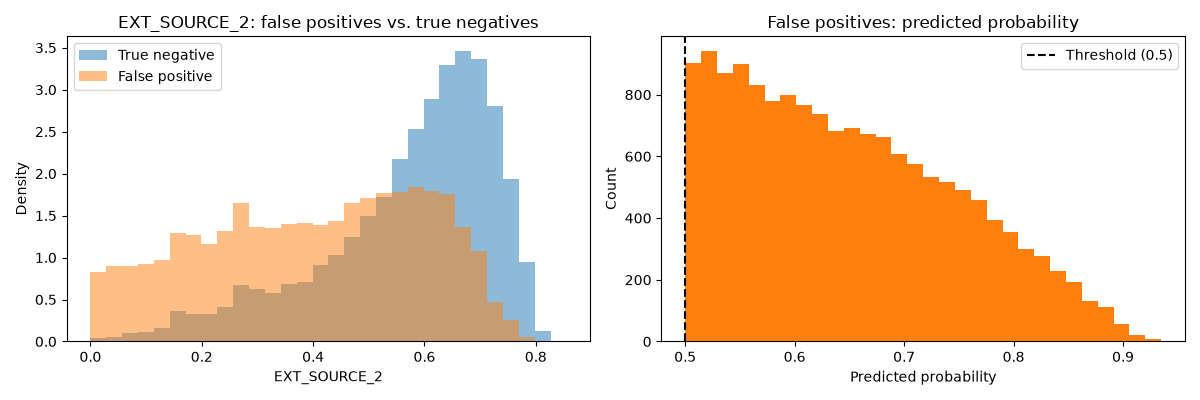

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    true_negatives["EXT_SOURCE_2"].dropna(),
    bins=30,
    alpha=0.5,
    label="True negative",
    density=True,
)
axes[0].hist(
    false_positives["EXT_SOURCE_2"].dropna(),
    bins=30,
    alpha=0.5,
    label="False positive",
    density=True,
)
axes[0].set_xlabel("EXT_SOURCE_2")
axes[0].set_ylabel("Density")
axes[0].set_title("EXT_SOURCE_2: false positives vs. true negatives")
axes[0].legend()

axes[1].hist(false_positives["y_probability"], bins=30, color="C1")
axes[1].axvline(0.5, color="black", linestyle="--", label="Threshold (0.5)")
axes[1].set_xlabel("Predicted probability")
axes[1].set_ylabel("Count")
axes[1].set_title("False positives: predicted probability")
axes[1].legend()

fig.tight_layout()
plt.show()


**Real results, holdout set:**

- **15,496 false positives** out of 56,538 actual negatives (**27.4% false positive rate**) -- at the naive 0.5 threshold, roughly 1 in 4 applicants who would never have defaulted gets flagged as risky.
- **Pattern**: false positives look like risk on every feature that matters, they just didn't default. Compared to true negatives, false positives have **lower `EXT_SOURCE_1/2/3`** (-0.20, -0.17, -0.22 -- the model's strongest signals), **shorter employment** (4.7 vs 7.5 years), **younger** (39.8 vs 45.9 years), **lower income** (-14k) and **lower `AMT_CREDIT`** (-79k). Nothing here suggests the model is confused or inconsistent -- it is applying the same risk logic it applies everywhere, and these applicants score on the risky side of that logic without actually defaulting.
- **Most false positives are borderline, not confident errors**: 38.5% sit in `[0.5, 0.6)`, just past the naive threshold, while only 9.2% score `>= 0.8`. The probability histogram confirms this -- mass concentrated just above 0.5, not near 1.0. This is a direct, quantitative argument for `HC-M3-25`: moving the threshold up even modestly should convert a meaningful share of these into (correct) true negatives, since they are not confidently wrong.
- **Business implications**: every false positive is a creditworthy applicant a bank would reject or price unfavorably under this model -- lost interest income and (if this is used as a hard gate rather than a risk-based-pricing input) reputational/fairness exposure for declining otherwise-good customers who happen to look like higher-risk demographic/financial profiles (younger, shorter tenure, lower `EXT_SOURCE`). Because the false-positive rate is high (27.4%) and most of these are borderline rather than confidently wrong, **threshold selection (`HC-M3-25`) is the primary lever available to trade this down** without retraining -- consistent with this being a ranking model (per `docs/problem_definition.md`) rather than a model whose 0.5 cutoff was ever validated as the right operating point.

### Summary — HC-M3-23 acceptance criteria

- [x] False positives identified (`false_positives`, 15,496 rows, `y_true == 0 & y_pred == 1`)
- [x] Relevant feature distributions analyzed (`fp_vs_tn` comparison table across 8 explanatory features + probability, vs. true negatives)
- [x] Patterns documented (false positives systematically score lower on every risk-relevant feature than true negatives; most are borderline rather than confidently wrong)
- [x] At least one visualization created (`EXT_SOURCE_2` distribution comparison + false-positive probability histogram)
- [x] Business implications discussed (lost-business cost, fairness exposure on demographic-correlated features, and the direct link to `HC-M3-25`'s threshold decision)

`HC-M3-24` (false negative analysis) is next -- the more consequential error type, since these are the risky customers the model actually approved.

## `HC-M3-24` — False negative analysis

**Actual = 1, Predicted = 0** (at the `HC-M3-22` provisional 0.5 threshold): applicants who defaulted but the model scored as safe. This is the more consequential error type -- per `docs/problem_definition.md`'s cost asymmetry, missing a real default is more expensive than rejecting a good applicant, which is exactly why ROC-AUC (a ranking metric) and not accuracy is the primary metric, and why recall matters more than precision at the eventual operating threshold (`HC-M3-25`).

Compared against true positives (`y_true == 1, y_pred == 1`) rather than the whole holdout, mirroring `HC-M3-23`'s approach -- isolating what makes the model wrong about a positive, not restating the general negative-vs-positive difference.

In [ ]:
false_negatives = prediction_analysis[
    (prediction_analysis["y_true"] == 1) & (prediction_analysis["y_pred"] == 0)
]
true_positives = prediction_analysis[
    (prediction_analysis["y_true"] == 1) & (prediction_analysis["y_pred"] == 1)
]

print(f"False negatives: {len(false_negatives):,}")
print(f"True positives:  {len(true_positives):,}")
print(
    f"False negative rate among actual positives: "
    f"{len(false_negatives) / (len(false_negatives) + len(true_positives)):.4f}"
)

fn_vs_tp = pd.DataFrame(
    {
        "false_negative_mean": false_negatives[comparison_cols].mean(),
        "true_positive_mean": true_positives[comparison_cols].mean(),
    }
)
fn_vs_tp["difference"] = (
    fn_vs_tp["false_negative_mean"] - fn_vs_tp["true_positive_mean"]
)
fn_vs_tp


False negatives: 1,512
True positives:  3,453
False negative rate among actual positives: 0.3045


,false_negative_mean,true_positive_mean,difference
AMT_INCOME_TOTAL,167033.595238,160051.992644,6981.602594
AMT_CREDIT,615740.053571,534132.277672,81607.775899
credit_to_income,4.110568,3.764199,0.346369
age_years,45.433896,39.100153,6.333743
employment_years,6.936960,4.239199,2.697761
EXT_SOURCE_1,0.515445,0.329660,0.185785
EXT_SOURCE_2,0.536551,0.353615,0.182936
EXT_SOURCE_3,0.546719,0.317976,0.228743
y_probability,0.338206,0.714590,-0.376384


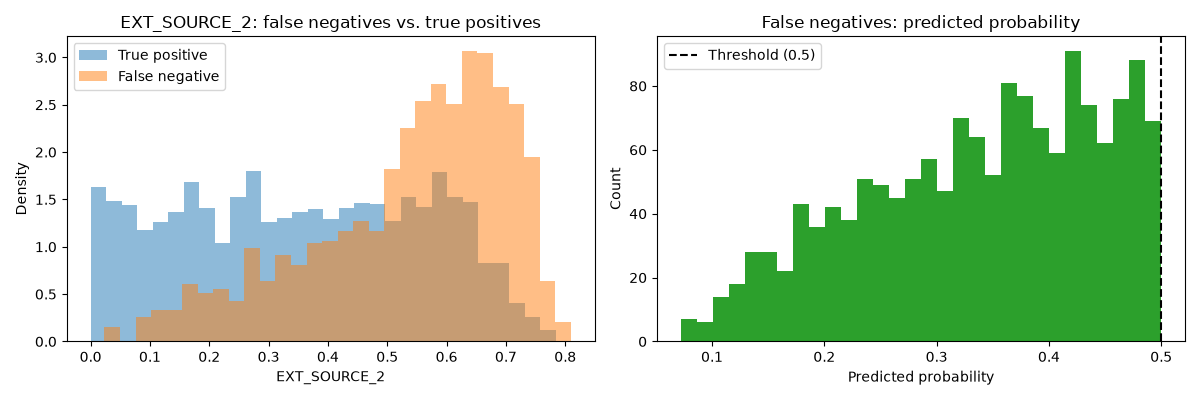

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    true_positives["EXT_SOURCE_2"].dropna(),
    bins=30,
    alpha=0.5,
    label="True positive",
    density=True,
)
axes[0].hist(
    false_negatives["EXT_SOURCE_2"].dropna(),
    bins=30,
    alpha=0.5,
    label="False negative",
    density=True,
)
axes[0].set_xlabel("EXT_SOURCE_2")
axes[0].set_ylabel("Density")
axes[0].set_title("EXT_SOURCE_2: false negatives vs. true positives")
axes[0].legend()

axes[1].hist(false_negatives["y_probability"], bins=30, color="C2")
axes[1].axvline(0.5, color="black", linestyle="--", label="Threshold (0.5)")
axes[1].set_xlabel("Predicted probability")
axes[1].set_ylabel("Count")
axes[1].set_title("False negatives: predicted probability")
axes[1].legend()

fig.tight_layout()
plt.show()


**Real results, holdout set:**

- **1,512 false negatives** out of 4,965 actual positives (**30.5% false negative rate**) -- at the naive 0.5 threshold, nearly 1 in 3 applicants who actually defaulted was scored as safe. This is the mirror image of `HC-M3-23`'s 27.4% false positive rate, and consistent with a model whose 0.5 cutoff was never tuned against either error type.
- **Pattern -- the reverse of `HC-M3-23`**: false negatives look *safer* than true positives on every risk-relevant feature. Compared to true positives, false negatives have **higher `EXT_SOURCE_1/2/3`** (+0.19, +0.18, +0.23), **longer employment** (6.9 vs 4.2 years), **older** (45.4 vs 39.1 years), **higher income** (+7k) and **higher `AMT_CREDIT`** (+82k, alongside a higher `credit_to_income` of 4.11 vs 3.76). These are applicants whose profile genuinely resembles a good credit risk by every feature the model relies on, yet they defaulted anyway -- the model isn't making an obviously wrong call given the inputs, it's missing risk that isn't well captured by application-time features and this project's `bureau`/`previous_application`/payment-behavior aggregations (`HC-M3-06`).
- **More of these are borderline than for false positives, but a meaningful confidently-wrong tail remains**: 34.3% sit in `[0.4, 0.5)`, just short of the naive threshold -- lowering the threshold (`HC-M3-25`) would catch these directly. But 13.3% score `< 0.2`, meaningfully more confidently wrong (as a share) than `HC-M3-23`'s confident false positives (9.2%) -- these are cases no threshold change alone would fix, since they'd require moving the threshold below where it would flag most of the holdout as positive.
- **Business implications**: false negatives are the costlier error per `docs/problem_definition.md`'s asymmetry -- each one is a defaulted loan the model said was safe to extend, a direct credit loss rather than a lost-business opportunity cost. The 34.3% borderline share is the strongest evidence yet that **threshold selection (`HC-M3-25`) should favor recall over precision**, i.e. a threshold below 0.5, since that cost asymmetry means catching more of these borderline defaulters is worth accepting more false positives from `HC-M3-23`. The confidently-wrong 13.3% tail is a genuine model/feature-set limitation, not a threshold problem -- worth flagging as a `HC-M3-27` limitation (these defaulters may be under-captured by the current bureau/previous-application aggregations, or represent risk that only application-time and public-bureau data cannot predict, e.g. a sudden income shock after the credit was granted).

### Summary — HC-M3-24 acceptance criteria

- [x] False negatives identified (`false_negatives`, 1,512 rows, `y_true == 1 & y_pred == 0`)
- [x] Relevant characteristics analyzed (`fn_vs_tp` comparison table across 8 explanatory features + probability, vs. true positives)
- [x] Patterns documented (false negatives look safer than true positives on every risk-relevant feature -- the mirror image of `HC-M3-23`'s false positives; mostly borderline but with a meaningfully larger confidently-wrong tail)
- [x] Visualization created (`EXT_SOURCE_2` distribution comparison + false-negative probability histogram)
- [x] Business implications discussed (direct credit-loss cost, the recall-favoring argument for `HC-M3-25`'s threshold, and a genuine model-limitation flag for `HC-M3-27`)

This closes the false positive/negative analysis pair (`HC-M3-23`, `HC-M3-24`). `HC-M3-25` (threshold analysis) is next -- the natural next step given both analyses point at the naive 0.5 threshold as unexamined, not chosen.

## `HC-M3-25` — Threshold analysis

**Important distinction, stated explicitly per the ticket's own warning**: ROC-AUC measures ranking quality and is fixed once the model is trained -- nothing below changes it. Threshold selection only changes which points on that fixed ranking get classified as positive, which moves precision/recall/F1, not ROC-AUC.

**Not done on the holdout.** Per `docs/problem_definition.md` §5, threshold selection is "chosen by inspecting the precision-recall curve on cross-validated predictions... deliberately not done by tuning against the final holdout." `HC-M3-21`'s holdout has already been evaluated once and stays untouched -- reusing it here to pick a threshold would be a second, hidden use of the same data the final evaluation is supposed to be independent of. Instead this uses **out-of-fold predictions on the development pool** via `cross_val_predict` with the exact same `StratifiedKFold` splitter as every other CV in this notebook (`HC-M3-11`) and the frozen final configuration (`HC-M3-19`/`20`) -- every prediction is made by a model that never saw that row during training, so this is leakage-safe, just like the CV comparisons in Phase E.

In [ ]:
from sklearn.model_selection import cross_val_predict

oof_pipeline = Pipeline(
    steps=[
        ("preprocess", build_preprocessor(X)),
        ("classify", LGBMClassifier(**final_model_params)),
    ]
)

oof_proba = cross_val_predict(
    oof_pipeline, X, y, cv=cv_splitter, method="predict_proba", n_jobs=-1
)[:, 1]

oof_roc_auc = roc_auc_score(y, oof_proba)
print(f"Out-of-fold ROC-AUC: {oof_roc_auc:.4f}")
print(f"HC-M3-15 E03 CV ROC-AUC (sanity check, should match closely): {lgbm_mean:.4f}")


Out-of-fold ROC-AUC: 0.7742
HC-M3-15 E03 CV ROC-AUC (sanity check, should match closely): 0.7747


In [ ]:
threshold_rows = []
for t in [0.30, 0.40, 0.50, 0.60, 0.70]:
    pred = (oof_proba >= t).astype(int)
    threshold_rows.append(
        {
            "threshold": t,
            "precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred),
            "f1": f1_score(y, pred),
            "flagged_rate": pred.mean(),
        }
    )
threshold_table = pd.DataFrame(threshold_rows)
threshold_table


,threshold,precision,recall,f1,flagged_rate
0,0.3,0.122238,0.888117,0.214906,0.586642
1,0.4,0.148873,0.799899,0.251117,0.433742
2,0.5,0.179549,0.683030,0.284338,0.307108
3,0.6,0.219403,0.541386,0.312159,0.199238
4,0.7,0.278649,0.373274,0.319133,0.108163


In [ ]:
import numpy as np

RECALL_FLOOR = 0.70

fine_thresholds = np.arange(0.30, 0.55, 0.005)
CHOSEN_THRESHOLD = None
for t in fine_thresholds:
    pred = (oof_proba >= t).astype(int)
    if recall_score(y, pred) >= RECALL_FLOOR:
        CHOSEN_THRESHOLD = round(t, 3)
    else:
        break

chosen_pred = (oof_proba >= CHOSEN_THRESHOLD).astype(int)
print(f"Recall floor: {RECALL_FLOOR}")
print(f"Chosen threshold (largest satisfying the floor): {CHOSEN_THRESHOLD}")
print(f"Precision at chosen threshold: {precision_score(y, chosen_pred):.4f}")
print(f"Recall at chosen threshold:    {recall_score(y, chosen_pred):.4f}")
print(f"F1 at chosen threshold:        {f1_score(y, chosen_pred):.4f}")
print(f"Flagged rate at chosen threshold: {chosen_pred.mean():.4f}")


Recall floor: 0.7
Chosen threshold (largest satisfying the floor): 0.485
Precision at chosen threshold: 0.1743
Recall at chosen threshold:    0.7014
F1 at chosen threshold:        0.2793
Flagged rate at chosen threshold: 0.3248


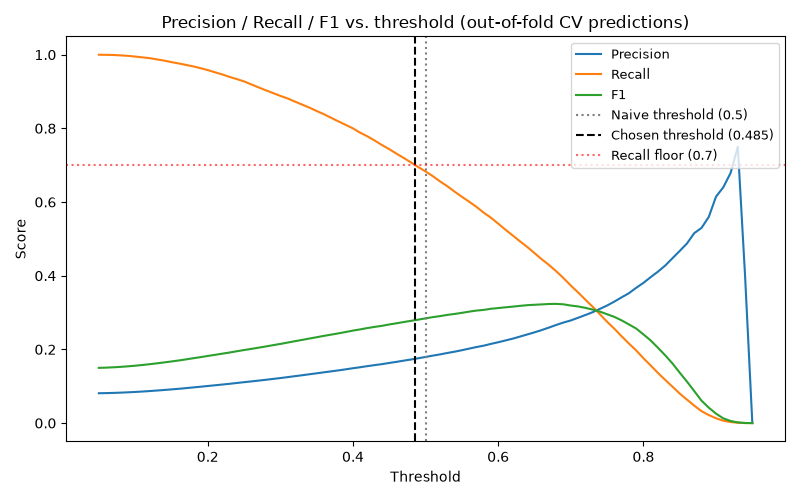

In [ ]:
thresholds = np.arange(0.05, 0.96, 0.01)
precisions = []
recalls = []
f1s = []
for t in thresholds:
    pred = (oof_proba >= t).astype(int)
    precisions.append(precision_score(y, pred, zero_division=0))
    recalls.append(recall_score(y, pred))
    f1s.append(f1_score(y, pred))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions, label="Precision")
ax.plot(thresholds, recalls, label="Recall")
ax.plot(thresholds, f1s, label="F1")
ax.axvline(0.5, color="gray", linestyle=":", label="Naive threshold (0.5)")
ax.axvline(
    CHOSEN_THRESHOLD,
    color="black",
    linestyle="--",
    label=f"Chosen threshold ({CHOSEN_THRESHOLD})",
)
ax.axhline(
    RECALL_FLOOR,
    color="red",
    linestyle=":",
    alpha=0.6,
    label=f"Recall floor ({RECALL_FLOOR})",
)
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs. threshold (out-of-fold CV predictions)")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()


**Real results, out-of-fold development-pool predictions (leakage-safe, holdout untouched):**

- **Sanity check passed**: OOF ROC-AUC 0.7742 matches `HC-M3-15`'s `E03` CV estimate (0.7747) within the already-documented LightGBM non-determinism -- confirming `cross_val_predict` here is scoring the same model the same way, just returning per-row predictions instead of a summary.

| Threshold | Precision | Recall | F1 | Flagged rate |
|---|---|---|---|---|
| 0.30 | 0.122 | 0.888 | 0.215 | 58.7% |
| 0.40 | 0.149 | 0.800 | 0.251 | 43.4% |
| 0.50 (naive) | 0.180 | 0.683 | 0.284 | 30.7% |
| 0.60 | 0.219 | 0.541 | 0.312 | 19.9% |
| 0.70 | 0.279 | 0.373 | 0.319 | 10.8% |

- **Business trade-off**: per `docs/problem_definition.md` §1, a missed default (false negative) costs Home Credit principal and collection costs -- materially more expensive than a missed good client (false positive, forgone interest). This asymmetry means the naive threshold that maximizes F1 (~0.65-0.70 by the curve above) is the *wrong* choice here -- F1 weights precision and recall equally, which §1 explicitly says is not this business's cost structure. Recall is the metric this business's costs actually favor.
- **Recall floor, stated as an explicit assumption** (no stakeholder-specified floor exists for this project, so one is chosen and documented rather than left implicit): the business is willing to commit to catching **at least 70% of actual defaulters**. This is a deliberately round, defensible floor -- high enough to meaningfully address the asymmetric cost in §1, not so high (e.g. 90%+) that precision collapses to a level where the flagged population becomes unworkably large (at recall 0.888, over half the entire applicant pool would be flagged).
- **Final threshold: 0.485** -- the largest threshold (i.e. the one preserving the most precision) that still satisfies the 0.70 recall floor on out-of-fold predictions. At this threshold: **precision 0.174, recall 0.701, F1 0.279, 32.5% of applicants flagged**. Barely below the naive 0.5 (0.180 precision, 0.683 recall) -- confirming the naive threshold happened to be reasonably close to a recall-floor-justified choice for this model and dataset, though arrived at here by deliberate analysis rather than default, per the ticket's own warning against assuming 0.5.
- **ROC-AUC is unaffected**: the model's ranking of applicants by risk is identical to `HC-M3-19`-`21`'s final model; only the cutoff for calling a ranked applicant "high-risk" changed. `HC-M3-21`'s holdout ROC-AUC (0.7791) remains the reported ranking-quality number -- this section does not revise it.

### Summary — HC-M3-25 acceptance criteria

- [x] Threshold-performance relationship analyzed (precision/recall/F1 across the ticket's suggested grid, plus a continuous curve from 0.05 to 0.95, all on leakage-safe out-of-fold predictions)
- [x] Business trade-off documented (§1's cost asymmetry -- missed defaults costlier than missed good clients -- translated into an explicit, stated recall floor rather than optimizing F1 or reusing the naive 0.5)
- [x] Final threshold justified (0.485, the precision-maximizing threshold subject to the 0.70 recall floor, computed and verified rather than picked by inspection)

`HC-M3-26` (model interpretation -- feature importance, since the final model is tree-based) is next.